In [47]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd, numpy as np

In [48]:
# 데이터 로드

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
x_data = cancer.data.values
y_data = cancer.target

In [49]:
# train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, random_state=42, stratify=y_data
)

In [50]:
# 스케일링
cancer_ss = StandardScaler()
train_ss = cancer_ss.fit_transform(x_train)
test_ss = cancer_ss.transform(x_test)

In [51]:
# 학습
cancer_lr = LogisticRegression()
cancer_lr.fit(train_ss, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [52]:
print(cancer_lr.classes_)
print(cancer_lr.coef_)
print(cancer_lr.intercept_)
print(cancer_lr.predict_proba(test_ss[:5]).round(2))

[0 1]
[[-0.5230639  -0.51866977 -0.48369147 -0.55733419 -0.3010073   0.69423027
  -0.56544331 -0.6769288  -0.12623296  0.08371349 -1.0701021   0.26071433
  -0.49107245 -0.94105896 -0.14558343  0.61642565  0.15410769 -0.34398572
   0.42510152  0.37488172 -0.91747951 -1.25014919 -0.72116803 -0.92581178
  -0.6696476   0.04658657 -0.79675795 -0.94188817 -0.95704524 -0.20956757]]
[0.28055487]
[[0.03 0.97]
 [1.   0.  ]
 [0.44 0.56]
 [0.06 0.94]
 [0.82 0.18]]


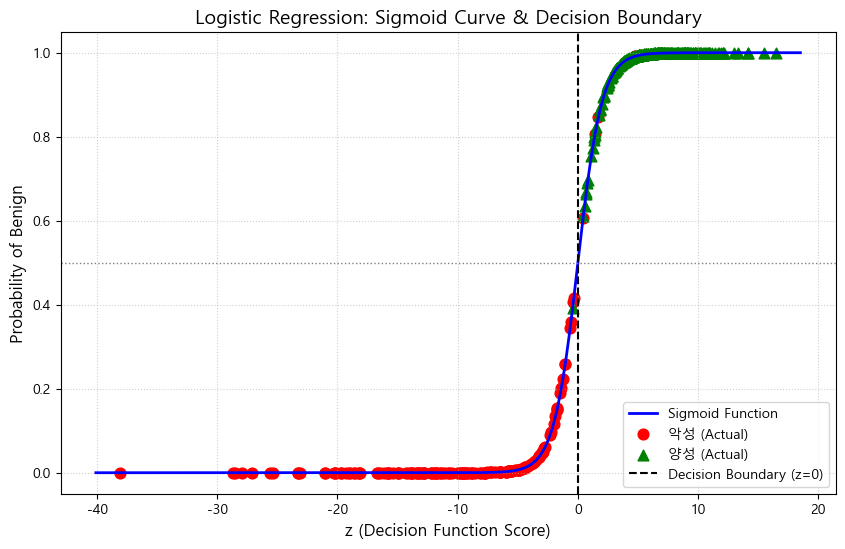

In [53]:
import matplotlib.pyplot as plt
from matplotlib import rc
import platform
from scipy.special import expit
import numpy as np

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    rc('font', family='AppleGothic')
elif platform.system() == 'Linux': # Colab 등
    rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False 


# 1. 전체 데이터셋의 z값(결정 함수 출력값) 계산
z_values = cancer_lr.decision_function(train_ss)
probabilities = expit(z_values)

# 2. 부드러운 시그모이드 곡선을 그리기 위해 촘촘한 z축 데이터 생성
z_axis = np.linspace(z_values.min() - 2, z_values.max() + 2, 500)
sigmoid_curve = expit(z_axis)

# 그래프 크기 설정 (matplotlib 규칙 준수)
plt.rcParams["figure.figsize"] = (10, 6)
plt.clf()

# 3. 시그모이드 기본 곡선 그리기
plt.plot(z_axis, sigmoid_curve, color='blue', linewidth=2, label='Sigmoid Function')

# 4. 실제 데이터 포인트 플로팅 (악성 vs 양성)
is_malignant = (y_train == 0)
is_benign = (y_train == 1)

# 악성은 대체로 z값이 음수이므로 확률이 0에 가깝고, 양성은 대체로 양수이므로 1에 가깝게 위치함.
plt.scatter(z_values[is_malignant], probabilities[is_malignant], color='red', marker='o', s=60, label='악성 (Actual)')
plt.scatter(z_values[is_benign], probabilities[is_benign], color='green', marker='^', s=60, label='양성 (Actual)')

# 5. 결정 경계 표시 (z = 0 이자 확률이 정확히 0.5인 지점)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Decision Boundary (z=0)')
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1)

# 축 이름 및 타이틀 설정
plt.title('Logistic Regression: Sigmoid Curve & Decision Boundary', fontsize=14)
plt.xlabel('z (Decision Function Score)', fontsize=12)
plt.ylabel('Probability of Benign', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

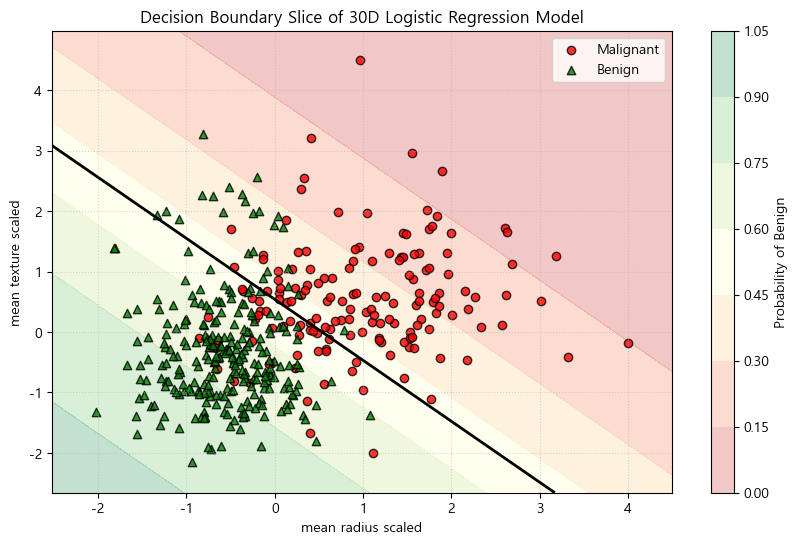

In [54]:
import numpy as np
import matplotlib.pyplot as plt

y_train_arr = np.asarray(y_train)

# 보고 싶은 특성 2개 선택
x_idx = 0  # mean radius
y_idx = 1  # mean texture

feature_1 = cancer.feature_names[x_idx]
feature_2 = cancer.feature_names[y_idx]

# x, y축 범위
x_min, x_max = train_ss[:, x_idx].min() - 0.5, train_ss[:, x_idx].max() + 0.5
y_min, y_max = train_ss[:, y_idx].min() - 0.5, train_ss[:, y_idx].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# 30개 특성짜리 grid 생성
# 나머지 특성은 0, 즉 표준화 기준 평균값으로 고정
grid = np.zeros((xx.ravel().shape[0], train_ss.shape[1]))

grid[:, x_idx] = xx.ravel()
grid[:, y_idx] = yy.ravel()

# 기존 30개 특성으로 학습된 cancer_lr 사용
Z = cancer_lr.predict_proba(grid)[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

contour = plt.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
plt.colorbar(contour, label='Probability of Benign')

plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

is_malignant = y_train_arr == 0
is_benign = y_train_arr == 1

plt.scatter(
    train_ss[is_malignant, x_idx],
    train_ss[is_malignant, y_idx],
    color='red',
    label='Malignant',
    edgecolor='k',
    alpha=0.8
)

plt.scatter(
    train_ss[is_benign, x_idx],
    train_ss[is_benign, y_idx],
    color='green',
    marker='^',
    label='Benign',
    edgecolor='k',
    alpha=0.8
)

plt.title('Decision Boundary Slice of 30D Logistic Regression Model')
plt.xlabel(f'{feature_1} scaled')
plt.ylabel(f'{feature_2} scaled')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [55]:
# confusion matrix

print('Train confusion matrix : ',confusion_matrix(y_train,cancer_train_pred),sep='\n')
print('Test confusion matrix : ',confusion_matrix(y_test,cancer_test_pred),sep='\n')

Train confusion matrix : 
[[155   4]
 [  1 266]]
Test confusion matrix : 
[[52  1]
 [ 1 89]]


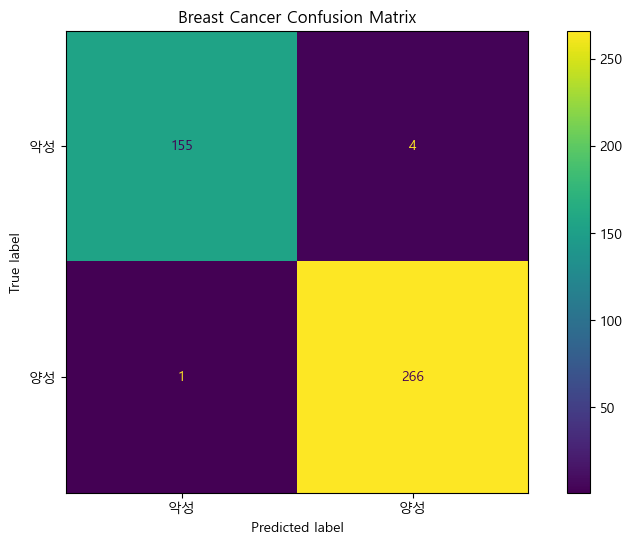

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 컨퓨전 매트릭스 생성
train_cm = confusion_matrix(y_train, cancer_train_pred)

# 클래스 이름
labels = ['악성', '양성']

# 시각화
disp = ConfusionMatrixDisplay(
    confusion_matrix=train_cm,
    display_labels=labels
)

disp.plot()
plt.title('Breast Cancer Confusion Matrix')
plt.show()

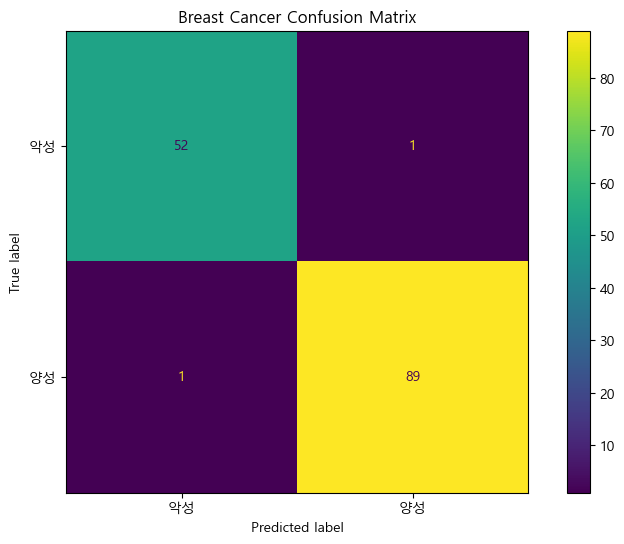

In [57]:
# 컨퓨전 매트릭스 생성
test_cm = confusion_matrix(y_test, cancer_test_pred)

# 클래스 이름
labels = ['악성', '양성']

# 시각화
disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=labels
)

disp.plot()
plt.title('Breast Cancer Confusion Matrix')
plt.show()

In [58]:

print('Train report : ',classification_report(y_train, cancer_train_pred),sep='\n')
print('='*60)
print('Test report : ',classification_report(y_test, cancer_test_pred),sep='\n')

Train report : 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       159
           1       0.99      1.00      0.99       267

    accuracy                           0.99       426
   macro avg       0.99      0.99      0.99       426
weighted avg       0.99      0.99      0.99       426

Test report : 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [59]:

cancer_train_pred = cancer_lr.predict(train_ss)
cancer_test_pred = cancer_lr.predict(test_ss)

cancer_train_acc = accuracy_score(y_train, cancer_train_pred)
cancer_test_acc = accuracy_score(y_test, cancer_test_pred)

print(f"Train 정확도: {cancer_train_acc:.4f}")
print(f"Test 정확도: {cancer_test_acc:.4f}")

Train 정확도: 0.9883
Test 정확도: 0.9860


- 0 = 악성
- 1 = 양성
- 전체 정확도 : accuracy 0.99
- class 0 :
    - 악성 예측 precision 0.99 / 0.98
    - 모델이 악성으로 제대로 찾아낸 비율 recall 0.97 / 0.98
- class 1 :
    - 양성 예측 precision 0.99 / 0.99
    - 모델이 양성으로 제대로 찾아낸 비율 recall 1.00 / 0.99
- macro avg : 0.99 (클래스0과 1 점수를 평균낸 값)
- weighted avg : 0.99 (각 클래스의 데이터 개수를 반영해서 평균낸 값)

#### ROC curve
---


#### 양성을 잘 맞출 확률

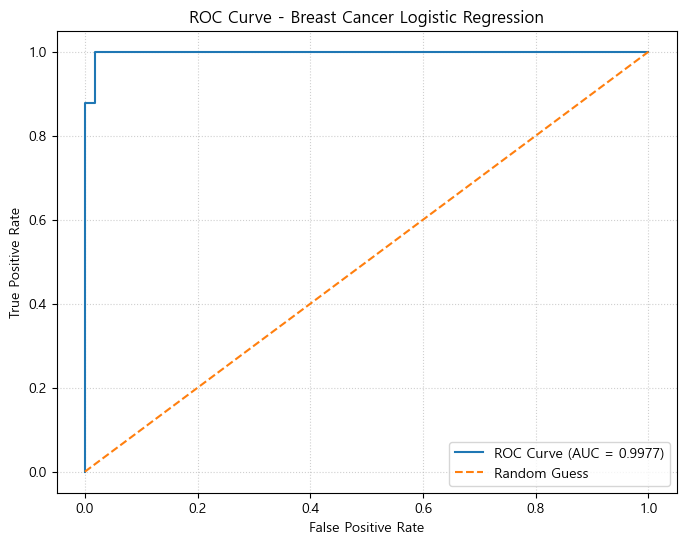

In [61]:
# ROC Curve 시각화
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# class 1, 즉 benign 양성일 확률
y_score = cancer_lr.predict_proba(test_ss)[:, 1]

# ROC 값 계산
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# AUC 점수 계산
auc_score = roc_auc_score(y_test, y_score)

# 시각화
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')

# 랜덤 분류 기준선
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Breast Cancer Logistic Regression')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()  

#### 악성을 잘 맞출 확률

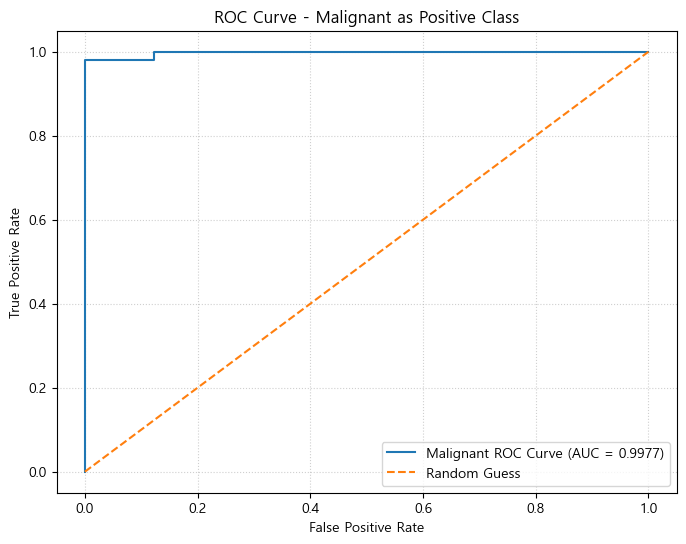

In [62]:
y_score_malignant = cancer_lr.predict_proba(test_ss)[:, 0]

fpr, tpr, thresholds = roc_curve(y_test, y_score_malignant, pos_label=0)
auc_score = roc_auc_score(y_test == 0, y_score_malignant)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Malignant ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Malignant as Positive Class')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

- x축 FPR = 실제 0인데 1이라고 잘못 예측한 비율
- y축 TPR = 실제 1을 1로 잘 맞춘 비율 = Recall
- AUC = ROC 곡선 아래 면적

훈련 정확도는 0.9883, 테스트 정확도는 0.9860으로 두 점수의 차이가 매우 작다.
classification_report에서도 train/test의 precision, recall, f1-score가 모두 0.98~0.99 수준으로 유사하게 나타났다.
따라서 현재 로지스틱 회귀 모델은 과적합이 거의 발생하지 않았으며, 테스트 데이터에 대해서도 안정적으로 일반화되고 있다고 볼 수 있다.